In [1]:
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt
from qiskit.dagcircuit import DAGCircuit, DAGOpNode, DAGInNode, DAGOutNode
from qiskit.converters import circuit_to_dag, dag_to_circuit
import networkx as nx

from dac_part import * #remove_1q_and_consecutive_2q_gates_in_circuit, get_interaction_graph, graph_profile
from collections import defaultdict
#from dac_part import get_interaction_graph

from ag import qgrid, q20
import time
import os

grover电路很有特点，顶点逐次增加。可以用归纳法研究一下它的最优转换：例如Grover_10某一段牵涉的边都是从5出发，到6，7，8，9；下一段都是从4出发，到5--9，而且（4，5）只出现一两次，可以分块处理。先处理完【5-9】这一块，然后把4，5交换，就可以处理【4-9】这一块，然后依次类推。它的分块是根据牵涉的qubit的：[8, 9] | [7,8,9] | [6,7,8,9] | ....| [0,1,...,9] 而且分块之间的联系都是通过大小相邻，例如（4，5）这样的边一次或两次连接，很有规律。假设前面的块（例如最小的qubit是5）有了最优解，下面的块只需把4传送到5就可以了。这样至少会得到一个很好的解，而且对任意AG都适用。

{*The following reasoning is not valid.*}

For grover_operator_k $C_k$ and a linear architecture, we need at most $k-2$ SWAPs. First, we define a dictionary $L$ s.t. $L[i]$ represents the layers an edge $(i,j)$ for some $j>i$ can occupy in the reduced circuit of $C_k$. We observe that $L[i]$ and $L[j]$ are disjoint if $i\not=j$. Suppose all gates involving $j+1$ and larger qubits, which form an endcircuit of the reduced circuit are transformed with $2(j-1)$ SWAPs with the trivial layout on the linear architecture. We put $j$ next to $j+1$. Swapping them will then solve all constraints involving $j$ and larger qubits. After that, we swap $j$ back and continue.   

In [2]:
def node_iterative(ig: nx.Graph):
    #if set(ig.nodes()) != set(range(len(ig.nodes()))):
    #    raise Exception (f'node error {ig.nodes()}')
    L = defaultdict(list)
    for k in ig.nodes():
        for i in ig.nodes():
            if i<=k or (i,k) not in ig.edges(): continue
            L[k] += ig.edges[(i,k)]['layer_distribution']
        L[k].sort()
    return L
        
def grover_graph_profile(qc: QuantumCircuit):
        #qc should be reduced first!
    redqc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)
    dag = circuit_to_dag(redqc)

    ig = get_interaction_graph(dag)
    print(f'The DAGCircuit has {dag.num_qubits()} qubits, depth {dag.depth()}, {dag.count_ops()}')
    
    L = node_iterative(ig)
    for k in ig.nodes():
        if not L[k]: 
            print(k, L[k])
        else:
            print(k, min(L[k]),max(L[k]))
    
    for k in ig.nodes:
        for i in ig.nodes():
            if i <= k: continue
            if set(L[k])&set(L[i]):
                print(f"There is a layer where there is a cx gate involving {k} and another cx gate involving {i} ")

In [3]:
"""grover_operator circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'grover_operator_5.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
qc.draw('mpl')
graph_profile(qc)
grover_graph_profile(qc)

The DAGCircuit has 5 qubits, depth 24, {'cx': 25}
3 0 7
4 []
2 1 22
0 2 23
1 3 21
There is a layer where there is a cx gate involving 0 and another cx gate involving 2 


orginal circuit info: ({'cx': 253}, 253)
The DAGCircuit has 10 qubits, depth 253, {'cx': 253}
~~~~~~~~~~~~~~~~~~~~~~~~
*node distribution*
~~~~~~~~~~~~~~~~~~~~~~~~
7 [0, 1, 3, 7, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51, 55, 59, 63, 67, 71, 75, 79, 83, 87, 91, 95, 99, 103, 107, 111, 115, 119, 123, 127, 131, 135, 139, 143, 147, 151, 155, 159, 163, 167, 171, 175, 179, 183, 187, 191, 195, 199, 203, 207, 211, 215, 219, 223, 227, 231, 235, 239, 243, 247, 251]
8 [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128, 130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154, 156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180, 182, 184, 186, 188, 190, 192, 194, 196, 198, 200, 202, 204, 206, 208, 210, 212, 214, 216, 218, 220, 222, 224, 226, 228, 230, 232, 234, 2

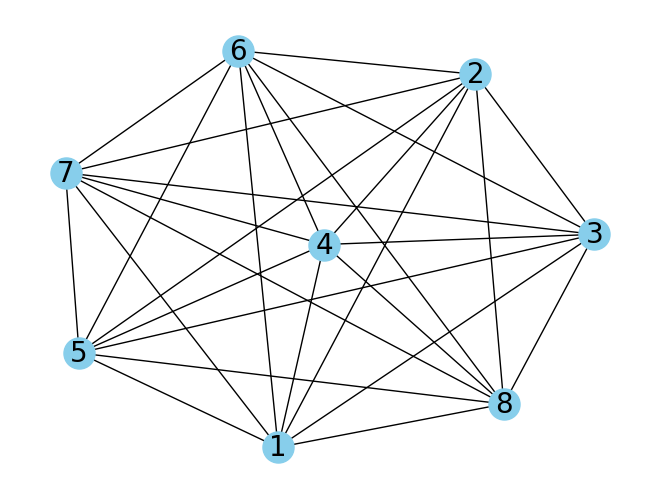

The cutting points are [0, 1, 4, 5, 12, 13, 28, 29, 60, 61, 124, 125, 252]
section 0: [0]


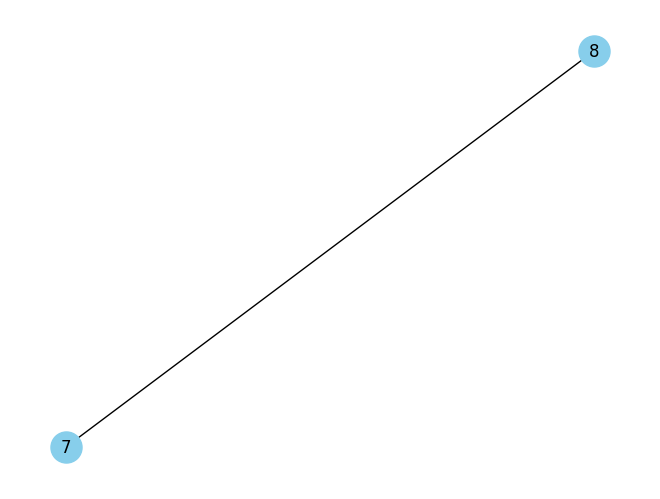

section 1: [1]


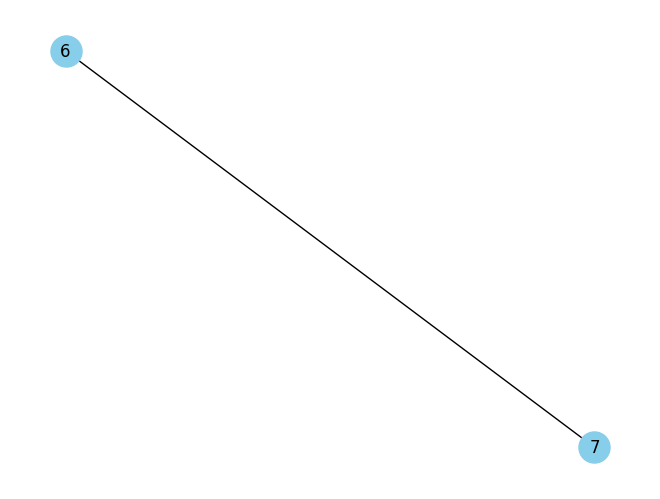

section 2: [2, 3, 4]


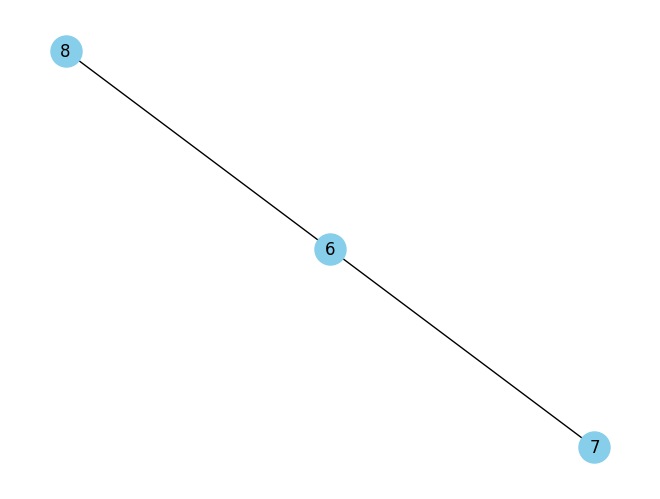

section 3: [5]


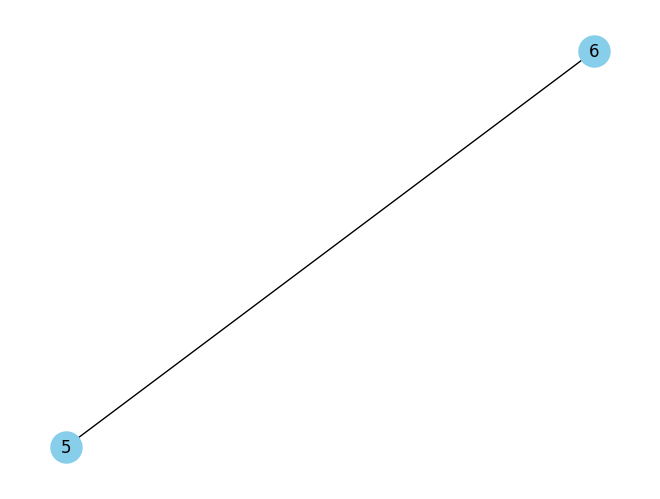

section 4: [6, 7, 8, 9, 10, 11, 12]


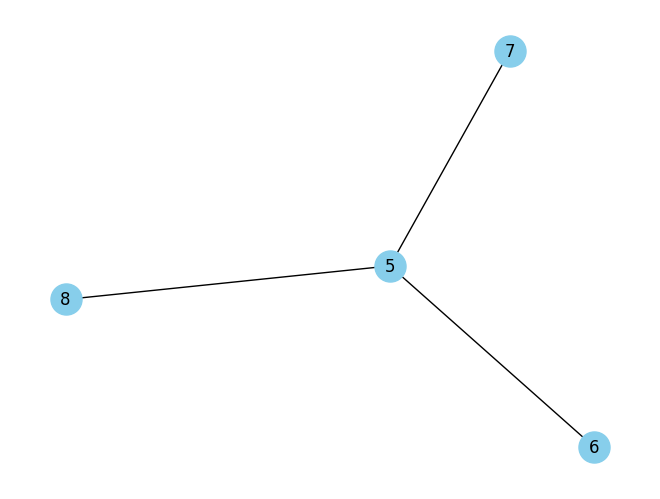

section 5: [13]


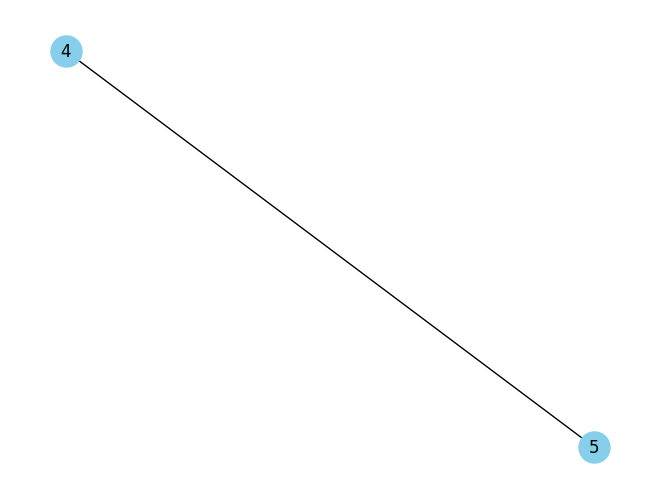

section 6: [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


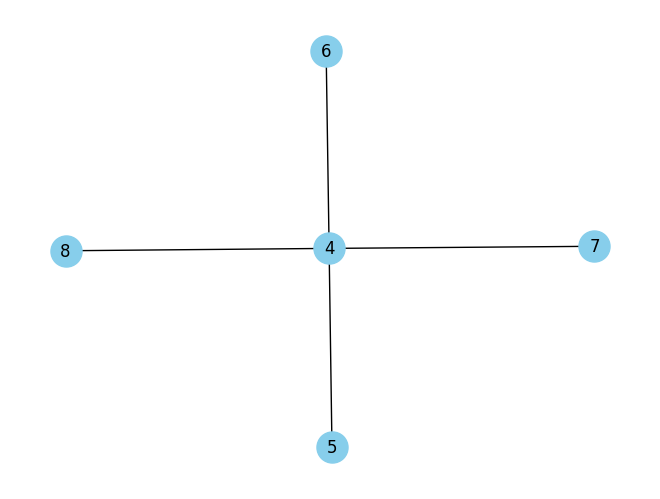

section 7: [29]


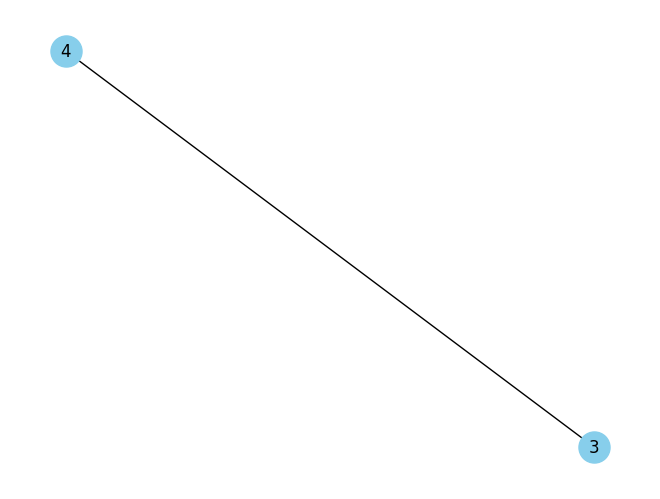

section 8: [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]


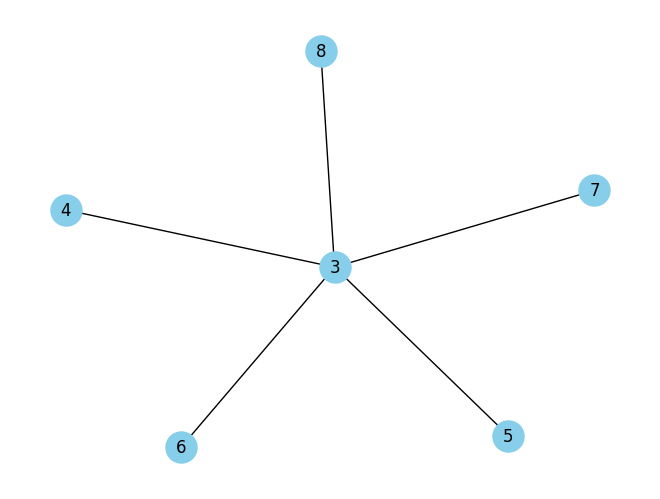

section 9: [61]


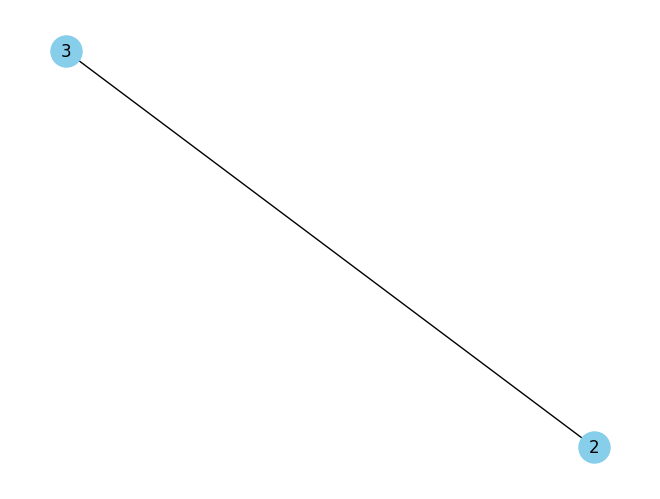

section 10: [62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124]


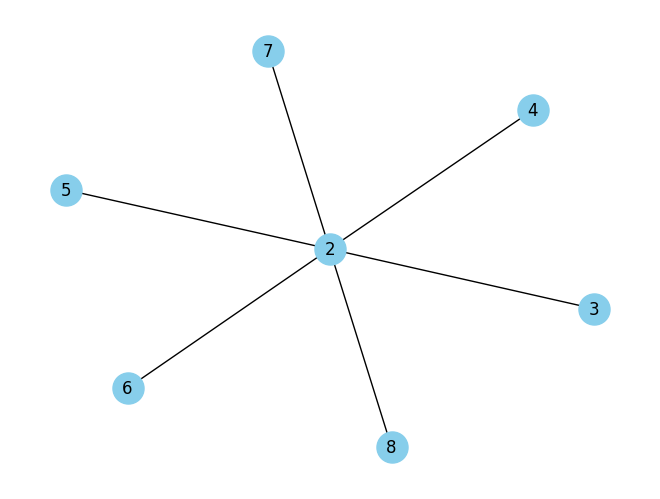

section 11: [125]


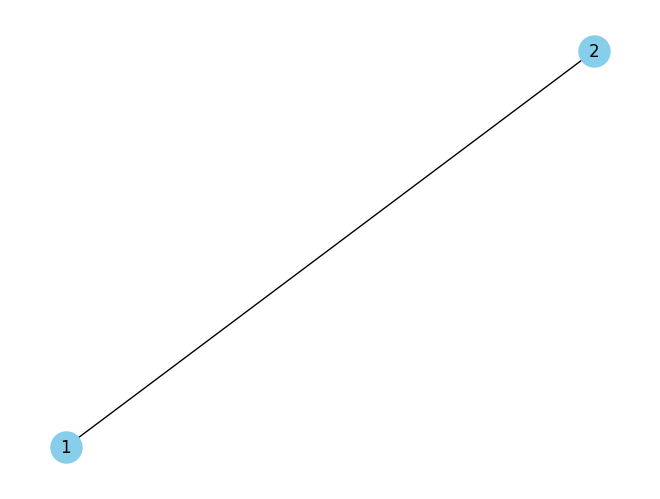

section 12: [126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252]


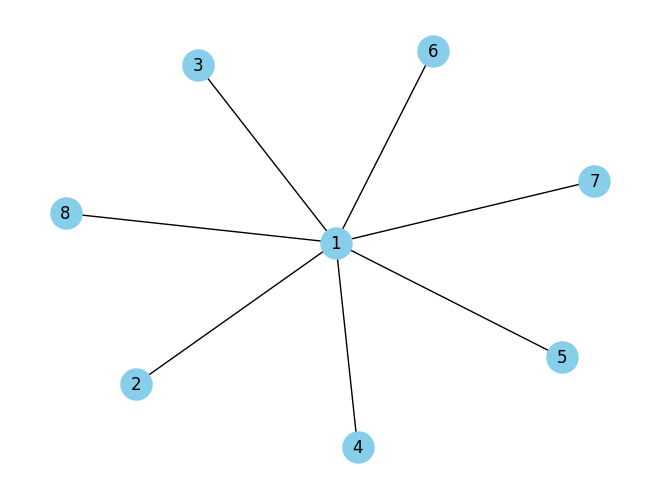

section 13: [252]


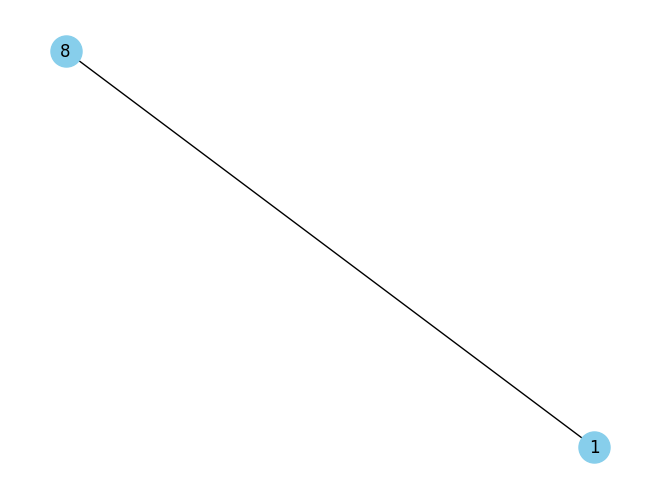

In [4]:
"""phase_oracle circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'phase_oracle_10.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
#graph_profile(qc)
dynamic_graph_partition(qc, lev=1)

orginal circuit info: ({'cx': 13}, 13)
The DAGCircuit has 6 qubits, depth 13, {'cx': 13}
~~~~~~~~~~~~~~~~~~~~~~~~
*node distribution*
~~~~~~~~~~~~~~~~~~~~~~~~
3 [0, 1, 3, 7, 11]
4 [0, 2, 4, 6, 8, 10, 12]
2 [1, 2, 3, 4, 5, 9]
1 [5, 6, 7, 8, 9, 10, 11, 12]
*edge distribution*
(3, 4) [0]
(3, 2) [1, 3]
(3, 1) [7, 11]
(4, 2) [2, 4]
(4, 1) [6, 8, 10, 12]
(2, 1) [5, 9]


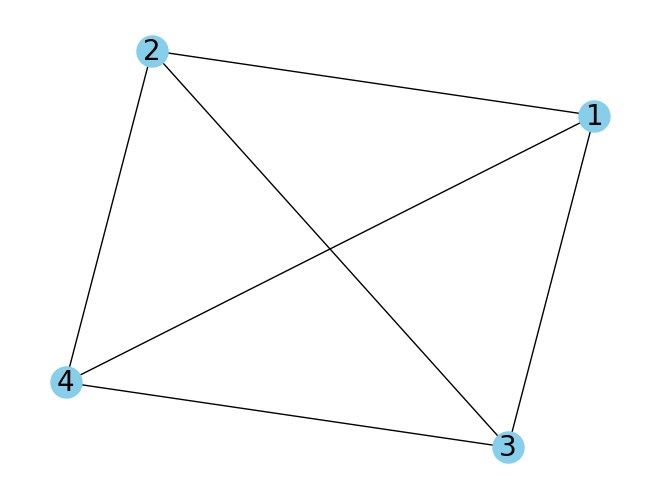

The cutting points are [0, 1, 4, 5, 12]
section 0: [0]


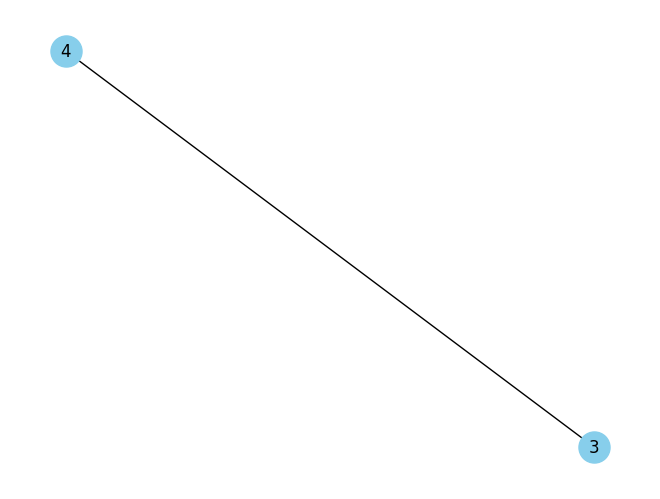

section 1: [1]


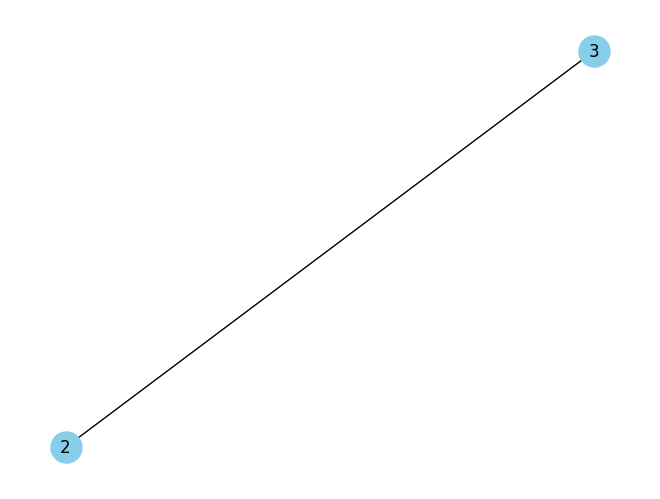

section 2: [2, 3, 4]


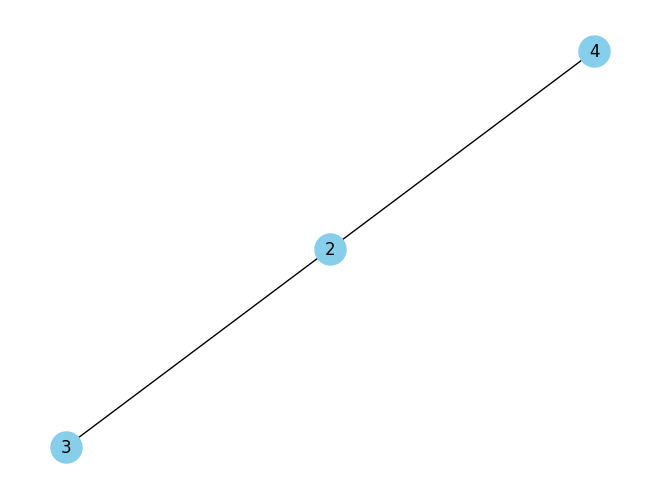

section 3: [5]


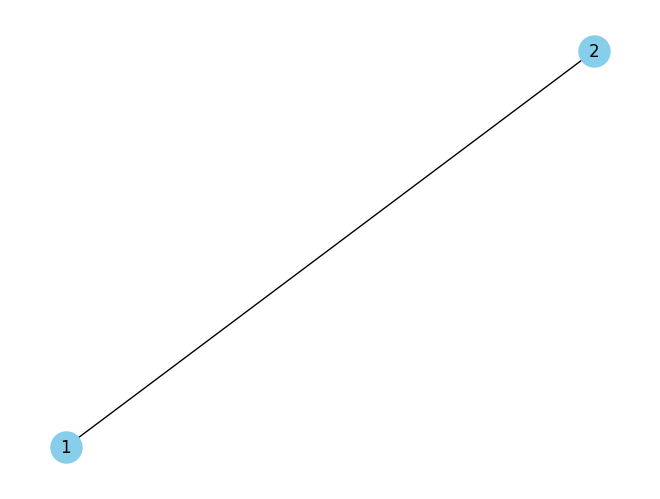

section 4: [6, 7, 8, 9, 10, 11, 12]


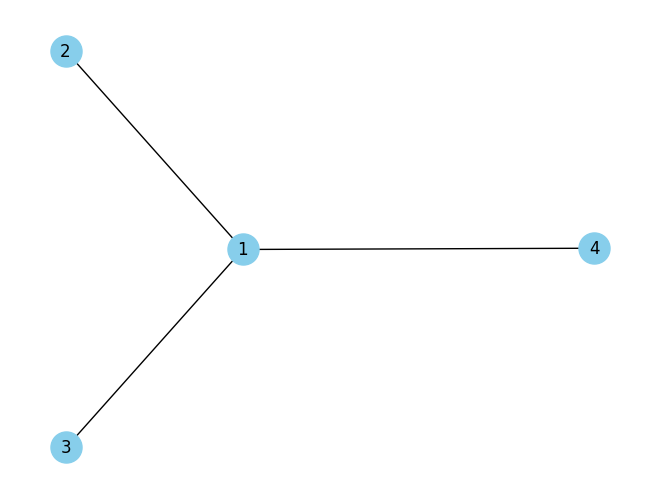

section 5: [12]


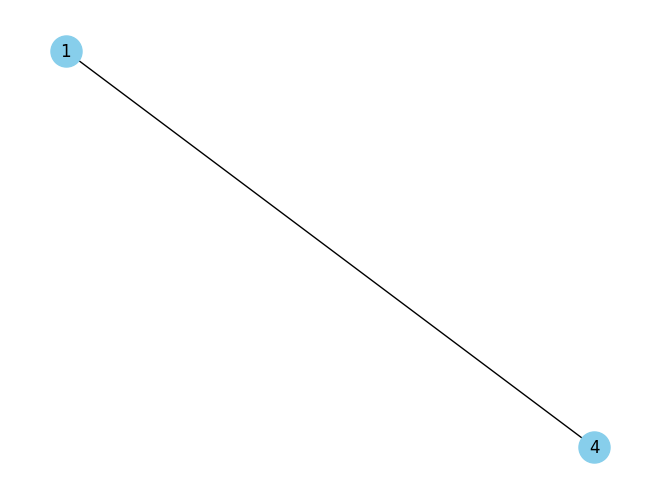

In [13]:
"""phase_oracle circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'phase_oracle_6.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
dynamic_graph_partition(qc, lev=1)